# Acoustic Full Waveform Inversion (FWI) with Marmousi2

Recover the Marmousi2 velocity model from seismic data using PyTorch autodiff.

Workflow:
1. Load Marmousi2 as the true velocity model
2. Generate observed data via acoustic forward modeling
3. Start from a smoothed initial model (shallow layers preserved)
4. Iterate: forward -> normalize -> misfit -> backward -> gradient mask -> update vp

---

**Full-Waveform Inversion (FWI)** recovers subsurface velocity structure by
minimising the misfit between observed and predicted seismic data.  This
notebook runs acoustic FWI on the Marmousi2 model using PyTorch autograd for
gradient computation.

> FWI is a non-linear, high-dimensional optimisation problem.  A good
> initial model is critical to avoid **cycle skipping** — local minima
> caused by phase ambiguity.

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.ndimage import gaussian_filter
from scipy.integrate import cumulative_trapezoid

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

from geobrain.physics.wave import (
    GridConfig,
    BoundaryConfig,
    AcousticModel,
    Source,
    Receiver,
    Survey,
    AcousticPropagator,
    RickerWavelet,
)
from geobrain.vis import plot_field

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(f"Using device: {device}")

Using device: cuda


## Step 1 — True Velocity Model

Load the Marmousi2 P-wave velocity as the ground truth.  Gardner's relation
provides the density.

In [2]:
def load_marmousi2_segy(segy_path: str):
    """Load Marmousi2 velocity model from SEGY file."""
    if not os.path.exists(segy_path):
        raise FileNotFoundError(f"SEGY file not found: {segy_path}")

    from geobrain.io import read_segy_volume
    vp_full, info = read_segy_volume(segy_path)

    dx_orig = 1.25  # Marmousi2 standard spacing
    dz_orig = 1.25

    if vp_full.max() < 10:
        vp_full = vp_full * 1000.0

    print(f"Loaded Marmousi2: {vp_full.shape[1]} x {vp_full.shape[0]} @ {dx_orig}m")
    print(f"Vp range: {vp_full.min():.0f} - {vp_full.max():.0f} m/s")
    return vp_full, dx_orig, dz_orig


def resample_marmousi2(vp_full, dx_orig, dz_orig, target_nx, target_nz,
                        x_start, dx_target, dz_target):
    """Resample Marmousi2 model to target grid."""
    nz_orig, nx_orig = vp_full.shape
    x_orig = np.arange(nx_orig) * dx_orig
    z_orig = np.arange(nz_orig) * dz_orig

    x_end = x_start + target_nx * dx_target
    z_end = target_nz * dz_target

    x_target = np.linspace(x_start, x_end - dx_target, target_nx)
    z_target = np.linspace(0, z_end - dz_target, target_nz)

    x_target = np.clip(x_target, x_orig.min(), x_orig.max() - dx_target)
    z_target = np.clip(z_target, z_orig.min(), z_orig.max() - dz_target)

    interp_func = interpolate.RegularGridInterpolator(
        (z_orig, x_orig), vp_full,
        method='linear', bounds_error=False, fill_value=None
    )

    Z_target, X_target = np.meshgrid(z_target, x_target, indexing='ij')
    points = np.stack([Z_target.ravel(), X_target.ravel()], axis=-1)
    vp_resampled = interp_func(points).reshape(target_nz, target_nx)

    print(f"Resampled to: {target_nx} x {target_nz} @ {dx_target}m")
    print(f"Vp range: {vp_resampled.min():.0f} - {vp_resampled.max():.0f} m/s")
    return vp_resampled


# Configuration
SEGY_FILE = "../data/marmousi/vp_marmousi-ii.segy"

NX = 200
NZ = 88
DX = 40.0
DZ = 40.0
X_START = 5000

NT = 3000
DT = 0.003
F0 = 5.0

print(f"Grid: {NX} x {NZ} @ {DX}m")
print(f"Time: {NT} samples @ {DT*1000:.1f}ms = {NT*DT:.2f}s")

print("\n--- Loading Marmousi2 ---")
vp_full, dx_orig, dz_orig = load_marmousi2_segy(SEGY_FILE)
vp_true = resample_marmousi2(
    vp_full, dx_orig, dz_orig,
    target_nx=NX, target_nz=NZ,
    x_start=X_START, dx_target=DX, dz_target=DZ,
)

# Density from Gardner's relation
rho_true = 310.0 * np.power(vp_true, 0.25)

print(f"True Vp range: {vp_true.min():.0f} - {vp_true.max():.0f} m/s")

Grid: 200 x 88 @ 40.0m
Time: 3000 samples @ 3.0ms = 9.00s

--- Loading Marmousi2 ---
Loaded Marmousi2: 13601 x 2801 @ 1.25m
Vp range: 1028 - 4700 m/s
Resampled to: 200 x 88 @ 40.0m
Vp range: 1500 - 4700 m/s
True Vp range: 1500 - 4700 m/s


## Step 2 — Survey Setup

Uniformly distributed sources and receivers, matching the acoustic forward
example.

In [3]:
grid = GridConfig(nx=NX, nz=NZ, dx=DX, dz=DZ)
boundary = BoundaryConfig(type='pml', n_layers=30, free_surface=True, alpha=0.007)

# Sources every 5 grid points
src_x = np.arange(2, NX - 1, 5)
src_z = np.ones_like(src_x) * 1
n_shots = len(src_x)

# Receivers at every grid point
rcv_x = np.arange(0, NX)
rcv_z = np.ones(NX, dtype=int) * 1

# Wavelet
ricker = RickerWavelet()
wavelet, _ = ricker(f0=F0, dt=DT)
wavelet_np = wavelet.numpy()
if len(wavelet_np) < NT:
    wavelet_np = np.pad(wavelet_np, (0, NT - len(wavelet_np)))

# Integrate for velocity source
src_wavelet = cumulative_trapezoid(wavelet_np, initial=0)

source = Source(nt=NT, dt=DT, f0=F0)
for i in range(n_shots):
    source.add_source(
        x=int(src_x[i]), z=int(src_z[i]),
        wavelet=src_wavelet,
        source_type='mt', moment_tensor=np.eye(3),
    )

receiver = Receiver(nt=NT, dt=DT)
receiver.add_receivers(x=rcv_x, z=rcv_z, rcv_type='pr')

survey = Survey(source=source, receiver=receiver)
print(f"Survey: {n_shots} shots, {len(rcv_x)} receivers")

Survey: 40 shots, 200 receivers


## Step 3 — Generate Observed Data

Run a forward simulation with the *true* model to produce the "observed"
data $\mathbf{d}_{\text{obs}}$.  In practice these come from field
acquisition.

In [4]:
print("\n--- Generating observed data ---")

model_true = AcousticModel(
    grid=grid, boundary=boundary,
    vp=vp_true, rho=rho_true,
    vp_grad=False,
    device=device, dtype=dtype,
)

propagator = AcousticPropagator(
    model=model_true, survey=survey,
    device=device, dtype=dtype,
)

with torch.no_grad():
    result_obs = propagator.forward(checkpoint_segments=10)

d_obs = result_obs['p'].detach().clone()
print(f"Observed data shape: {d_obs.shape}")


--- Generating observed data ---
Observed data shape: torch.Size([40, 3000, 200])


## Step 4 — Build Initial Model

A successful FWI start requires an initial model that captures the
**low-wavenumber** velocity trend:

- **Shallow layer**: kept at the true velocity (known from well logs or
  first-break tomography)
- **Deep layer**: Gaussian-smoothed (σ = 6 grid cells) version of the true
  model
- **Gradient mask**: zeros out gradients in the shallow zone to prevent
  updates to already-known structure

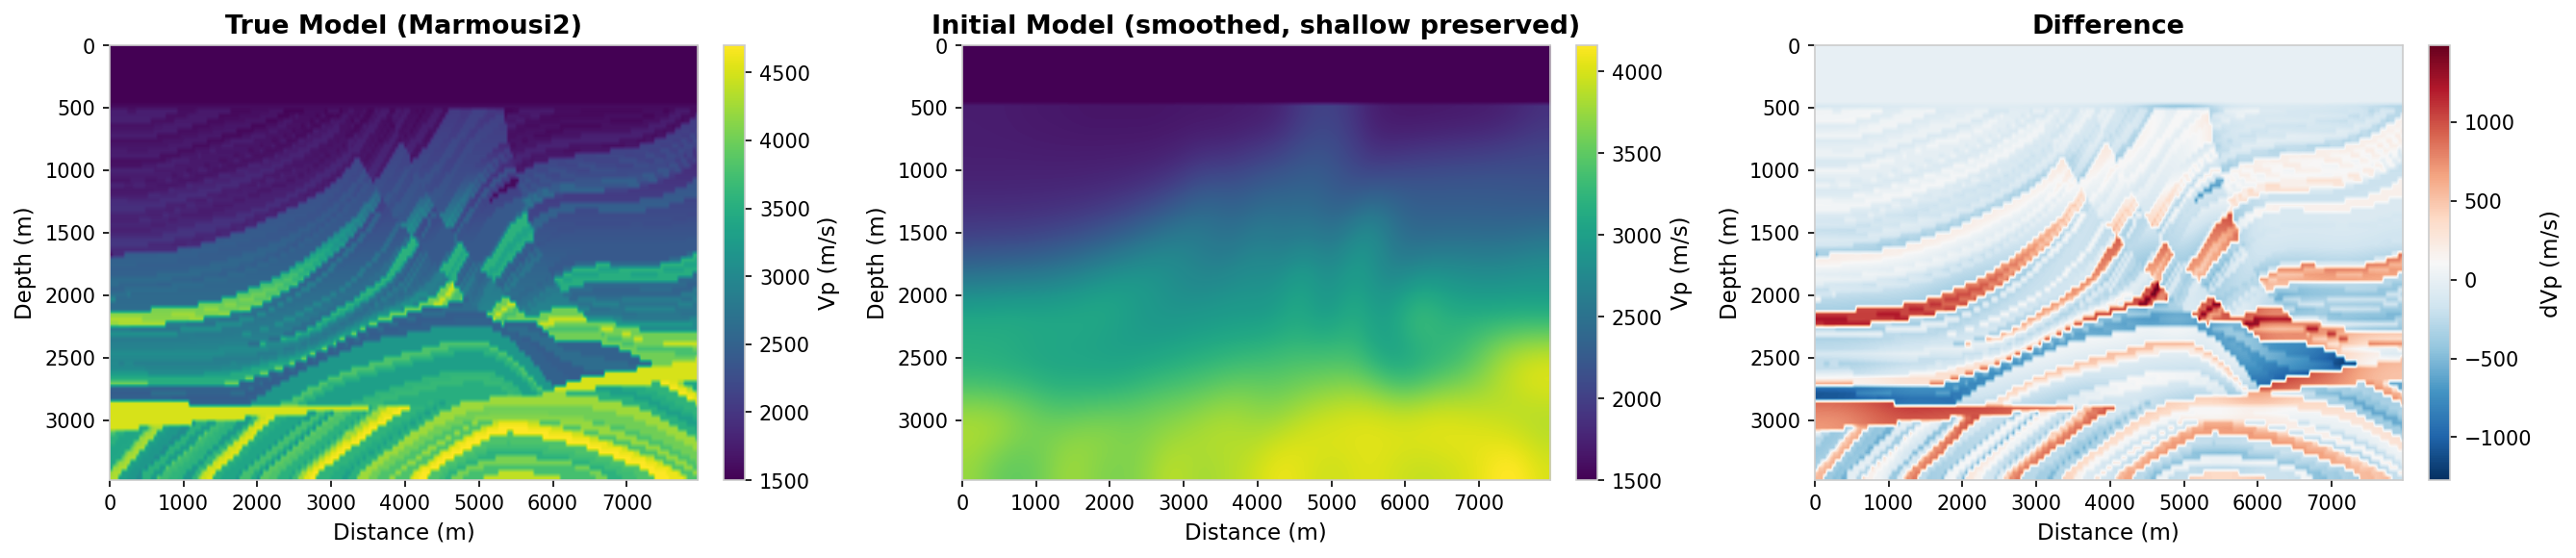

In [5]:
# Smooth only below receiver depth + extra margin (preserve shallow structure)
RCV_DEPTH = 10       # Receiver depth (grid points)
MASK_EXTRA_DEPTH = 2 # Extra rows to preserve below receiver
SMOOTH_KERNEL = 6    # Gaussian smoothing sigma

vp_init = vp_true.copy()
smooth_start = RCV_DEPTH + MASK_EXTRA_DEPTH  # row 12
vp_init[smooth_start:, :] = gaussian_filter(
    vp_true[smooth_start:, :],
    sigma=[SMOOTH_KERNEL, SMOOTH_KERNEL],
    mode='reflect',
)

# Gradient mask: zero out near-surface gradients
grad_mask = np.ones((NZ, NX), dtype=np.float32)
grad_mask[:smooth_start, :] = 0.0

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_field(vp_true, dx=DX, dz=DZ, ax=axes[0], cmap='viridis', label='Vp (m/s)')
axes[0].set_title('True Model (Marmousi2)')
plot_field(vp_init, dx=DX, dz=DZ, ax=axes[1], cmap='viridis', label='Vp (m/s)')
axes[1].set_title('Initial Model (smoothed, shallow preserved)')
plot_field(vp_true - vp_init, dx=DX, dz=DZ, ax=axes[2], cmap='RdBu_r', label='dVp (m/s)')
axes[2].set_title('Difference')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '09_initial_model.png'))
plt.show()

## Step 5 — FWI Iteration Loop

Each iteration performs:

1. **Forward modelling**: compute synthetic data with current velocity
2. **Trace normalisation**: reduce amplitude-mismatch effects
3. **Loss**: per-trace L2 norm, skipping zero-energy traces
4. **Backpropagation**: PyTorch autograd computes the velocity gradient
5. **Gradient masking**: zero out the shallow zone
6. **Update**: Adam optimiser with StepLR scheduler (LR drop at epoch 200)

In [6]:
print("\n--- Running FWI ---")

N_ITER = 300
LR = 10.0
CHECKPOINT_SEGMENTS = 10

# Create model with gradient enabled for vp
model_inv = AcousticModel(
    grid=grid, boundary=boundary,
    vp=vp_init.copy(), rho=rho_true.copy(),
    vp_grad=True,
    rho_grad=False,
    vp_bound=(float(vp_true.min()), float(vp_true.max())),
    auto_update_rho=True,
    device=device, dtype=dtype,
)

propagator_inv = AcousticPropagator(
    model=model_inv, survey=survey,
    device=device, dtype=dtype,
)

optimizer = torch.optim.Adam(model_inv.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=200, gamma=0.75,
)

# Gradient mask tensor
grad_mask_t = torch.tensor(grad_mask, device=device, dtype=dtype)

loss_history = []


def normalize_traces(data):
    """Normalize each trace by its max absolute value."""
    # data shape: (n_shots, nt, n_receivers) or similar
    max_vals = torch.max(torch.abs(data), dim=-2, keepdim=True).values
    # Avoid division by zero for silent traces
    max_vals = max_vals.clamp(min=1e-30)
    return data / max_vals


for it in range(N_ITER):
    optimizer.zero_grad()

    # Forward
    result = propagator_inv.forward(checkpoint_segments=CHECKPOINT_SEGMENTS)
    d_pred = result['p']

    # Normalize waveforms (trace-wise) before computing misfit
    d_obs_norm = normalize_traces(d_obs)
    d_pred_norm = normalize_traces(d_pred)

    # L2-norm misfit: sum over traces of sqrt(sum(residual^2))
    residual = d_obs_norm - d_pred_norm
    per_trace_l2 = torch.sqrt(torch.sum(residual ** 2, dim=-2))  # (n_shots, n_rcv)

    # Mask out zero traces
    trace_energy_obs = torch.sum(torch.abs(d_obs), dim=-2)
    trace_energy_syn = torch.sum(torch.abs(d_pred), dim=-2)
    active_mask = ~((trace_energy_obs == 0) & (trace_energy_syn == 0))

    loss = torch.sum(per_trace_l2[active_mask])

    # Backward
    loss.backward()

    # Apply gradient mask (zero out near-surface)
    if model_inv.vp.grad is not None:
        model_inv.vp.grad.data *= grad_mask_t

    optimizer.step()
    scheduler.step()

    # Constrain velocity bounds and auto-update density
    model_inv.forward()

    loss_val = loss.item()
    loss_history.append(loss_val)

    if it % 10 == 0 or it == N_ITER - 1:
        print(f"  Iter {it:3d}/{N_ITER}  loss = {loss_val:.6e}")

print("FWI complete.")


--- Running FWI ---
  Iter   0/300  loss = 7.480488e+04
  Iter  10/300  loss = 5.605745e+04
  Iter  20/300  loss = 4.561230e+04
  Iter  30/300  loss = 3.680011e+04
  Iter  40/300  loss = 3.086939e+04
  Iter  50/300  loss = 2.603362e+04
  Iter  60/300  loss = 2.218436e+04
  Iter  70/300  loss = 1.912054e+04
  Iter  80/300  loss = 1.649549e+04
  Iter  90/300  loss = 1.422467e+04
  Iter 100/300  loss = 1.241548e+04
  Iter 110/300  loss = 1.074204e+04
  Iter 120/300  loss = 9.480443e+03
  Iter 130/300  loss = 8.053908e+03
  Iter 140/300  loss = 6.932136e+03
  Iter 150/300  loss = 6.381053e+03
  Iter 160/300  loss = 4.894784e+03
  Iter 170/300  loss = 4.055316e+03
  Iter 180/300  loss = 3.388260e+03
  Iter 190/300  loss = 4.135518e+03
  Iter 200/300  loss = 2.749778e+03
  Iter 210/300  loss = 2.623929e+03
  Iter 220/300  loss = 2.538211e+03
  Iter 230/300  loss = 2.516315e+03
  Iter 240/300  loss = 2.444556e+03
  Iter 250/300  loss = 2.269686e+03
  Iter 260/300  loss = 2.222683e+03
  Iter 

## Step 6 — Results

Comparison panels:

- **True vs. Inverted** velocity model
- **Difference** map to identify unrecovered structure
- **Convergence** curve (loss vs. epoch)
- **Vertical profiles** at selected x-positions: true, initial, and inverted
  velocity overlaid

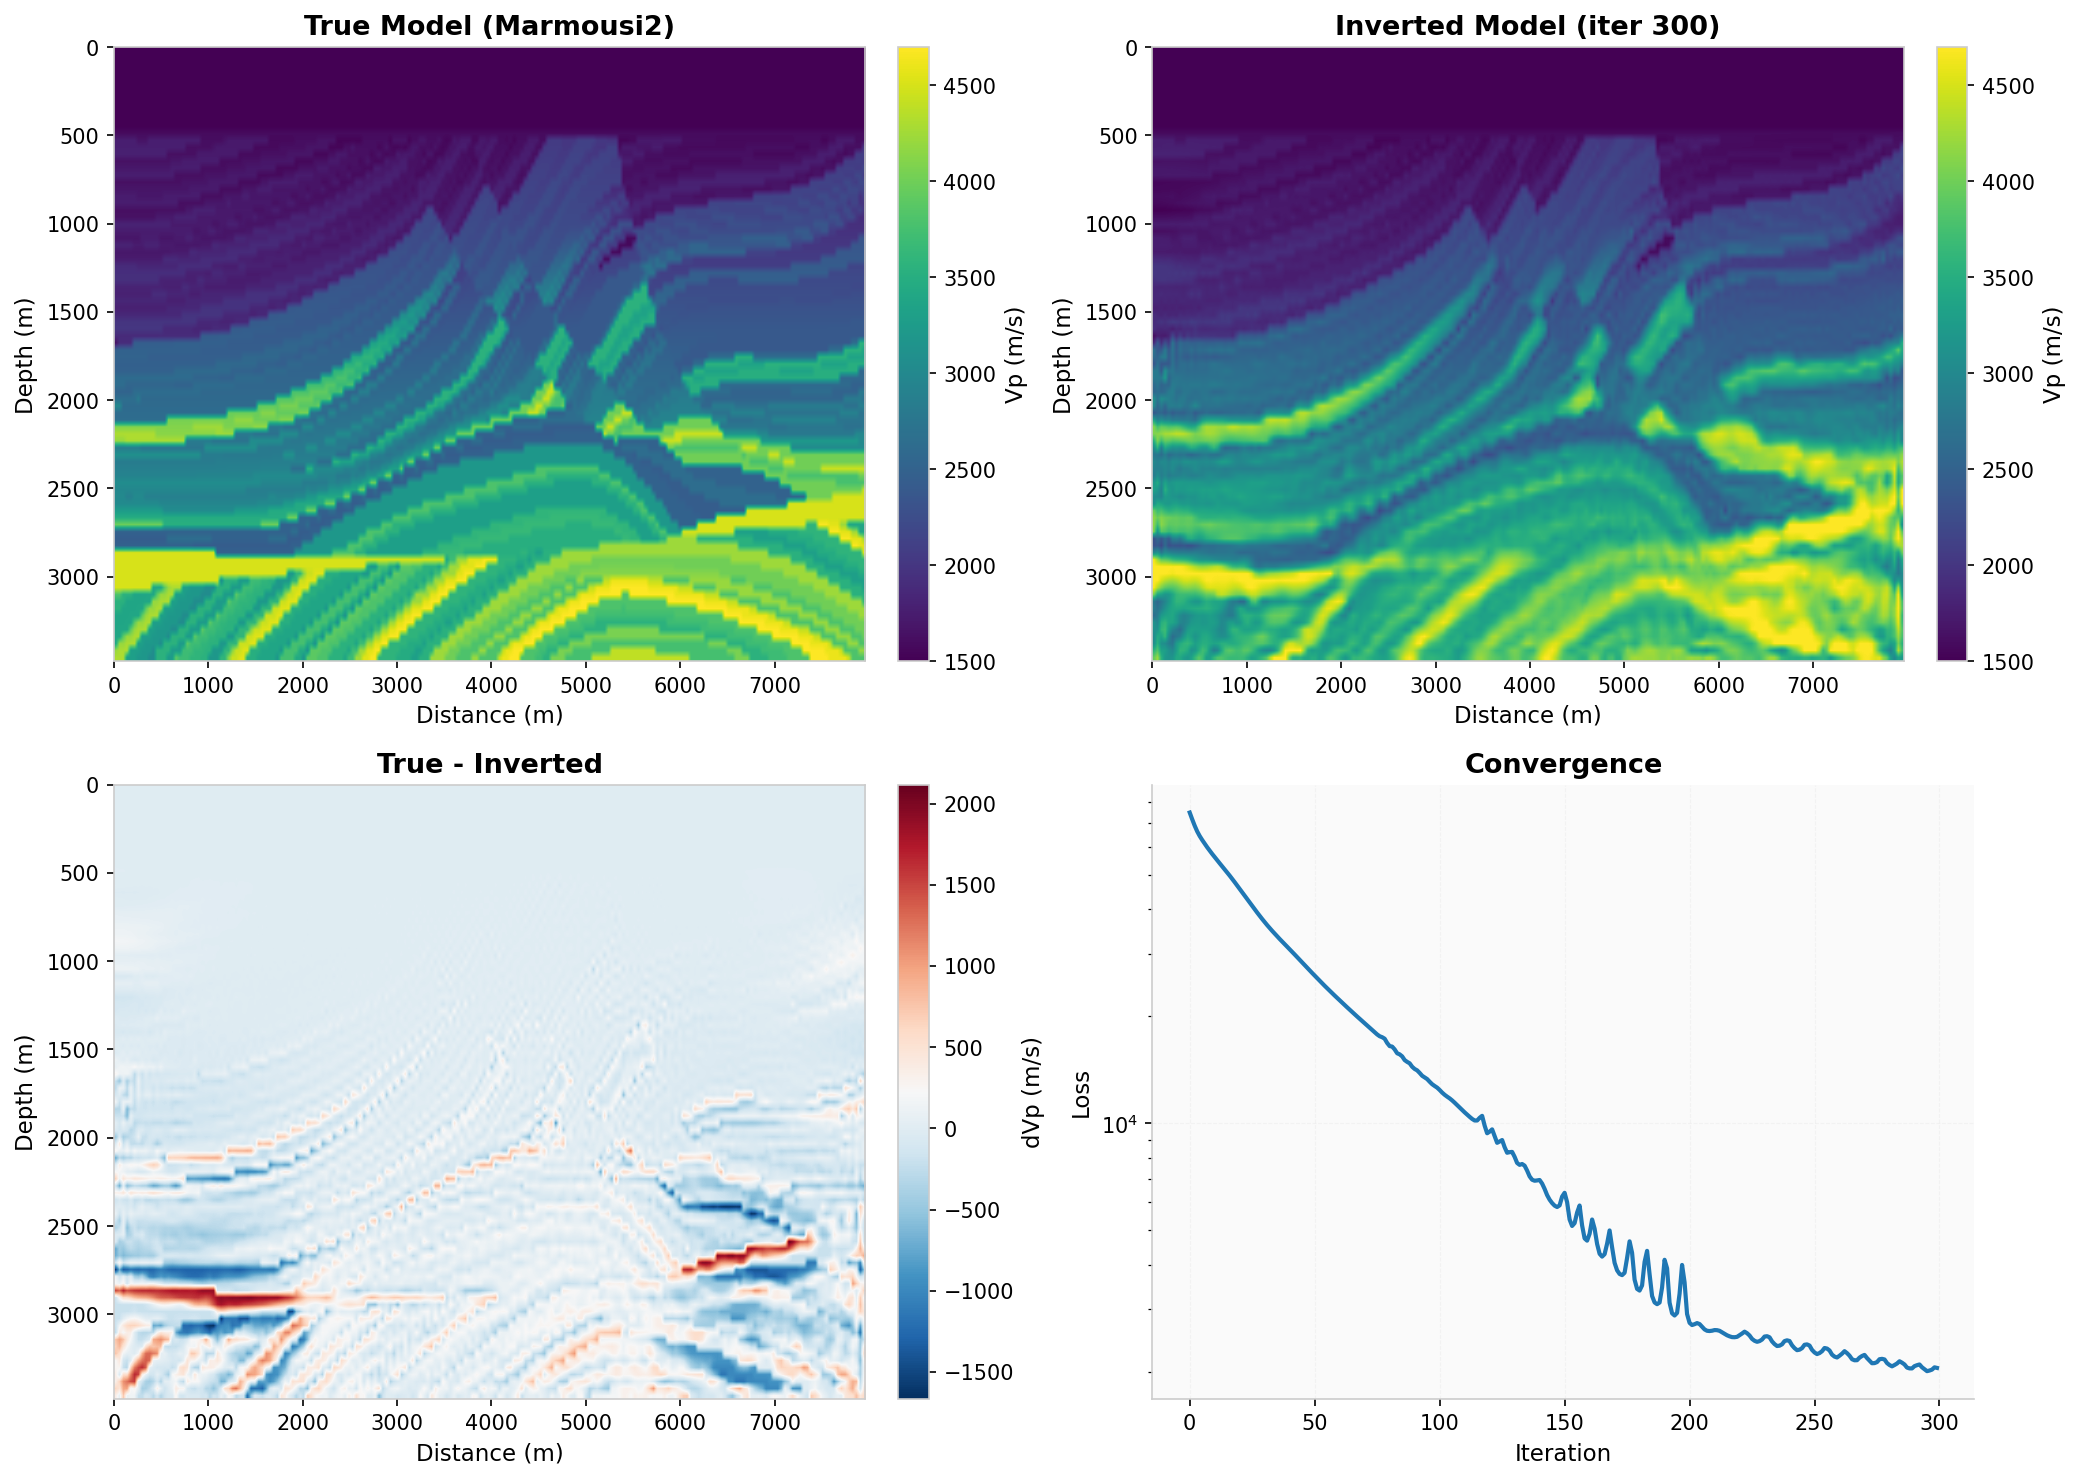

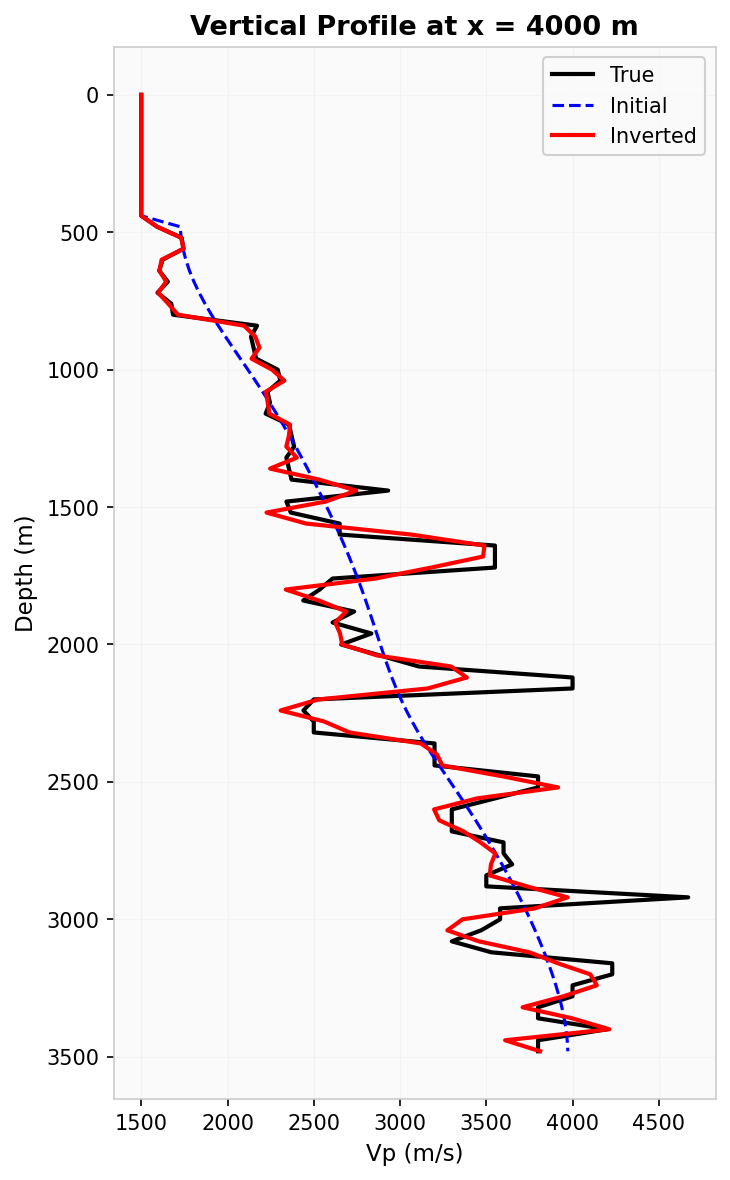

In [7]:
vp_inv = model_inv.vp.detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Models
plot_field(vp_true, dx=DX, dz=DZ, ax=axes[0, 0], cmap='viridis', label='Vp (m/s)')
axes[0, 0].set_title('True Model (Marmousi2)')

plot_field(vp_inv, dx=DX, dz=DZ, ax=axes[0, 1], cmap='viridis', label='Vp (m/s)')
axes[0, 1].set_title(f'Inverted Model (iter {N_ITER})')

# Difference
plot_field(vp_true - vp_inv, dx=DX, dz=DZ, ax=axes[1, 0], cmap='RdBu_r', label='dVp (m/s)')
axes[1, 0].set_title('True - Inverted')

# Convergence
axes[1, 1].semilogy(loss_history, color='#1f77b4', lw=2)
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Convergence')
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '09_fwi_results.png'))
plt.show()

# Vertical profile comparison
fig, ax = plt.subplots(figsize=(5, 8))
ix = NX // 2
ax.plot(vp_true[:, ix], np.arange(NZ) * DZ, 'k-', lw=2, label='True')
ax.plot(vp_init[:, ix], np.arange(NZ) * DZ, 'b--', lw=1.5, label='Initial')
ax.plot(vp_inv[:, ix], np.arange(NZ) * DZ, 'r-', lw=2, label='Inverted')
ax.invert_yaxis()
ax.set_xlabel('Vp (m/s)')
ax.set_ylabel('Depth (m)')
ax.set_title(f'Vertical Profile at x = {ix * DX:.0f} m')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()